In [1]:
# Cell 1: Environment Setup

include("helpers/initialization_helpers.jl")
include("helpers/initialization_dictionaries.jl")
using .InitializationHelpers
using .InitializationDictionaries
using OMJulia
using Plots, DataFrames, CSV

# --- Configuration ---

# 1. Directory containing the model files
MODEL_DIR = abspath("models")

# 2. Select the model to initialize
MODEL = "MyBESS"

# 3. Path to the selected dynamic case file
MODEL_FILE_PATH = joinpath(MODEL_DIR, MODEL * ".mo")

# 4. Name and path of the initialized dynamic case file
INITIALIZED_MODEL = MODEL * "_initialized"
INITIALIZED_FILE_PATH = joinpath(MODEL_DIR, INITIALIZED_MODEL * ".mo")

# 5. Path to the auxiliary file
AUX_MODEL = MODEL * "_auxiliary"
AUX_FILE_PATH = joinpath(MODEL_DIR, AUX_MODEL * ".mo")

# 6. Path to the Dynawo package.mo
DYNAWO_PKG_PATH = "/home/dyvulgawocfc/Model_library/dynawo/dynawo/sources/Models/Modelica/Dynawo/package.mo"

# 7. Path to the Modelica package.mo
MODELICA_PKG_PATH = "/home/dyvulgawocfc/dynawo/OpenModelica/lib/omlibrary/Modelica/package.mo"

# 8. Variable to plot after the initialized simulation
PLOT_VARIABLE = "BESS.terminal.V.im"


"BESS.terminal.V.im"

In [2]:
# Cell 2: OpenModelica Setup + Model Loading

# 1. Load the dynamic model
BESS = OMJulia.OMCSession()
sendExpression(BESS, "loadModel(Complex)")
sendExpression(BESS, "loadModel(ModelicaServices)")
ModelicaSystem(BESS, MODEL_FILE_PATH, "MyBESS", [MODELICA_PKG_PATH, DYNAWO_PKG_PATH])
sendExpression(BESS, "clearMessages()")
println("Checking the dynamic model...")
chk_dyn = sendExpression(BESS, "checkModel($MODEL)", parsed=false)
println(chk_dyn)

# 2. Load the auxiliary model
StaticBESS = OMJulia.OMCSession()
sendExpression(StaticBESS, "loadModel(Complex)")
sendExpression(StaticBESS, "loadModel(ModelicaServices)")
ModelicaSystem(StaticBESS, AUX_FILE_PATH, "MyBESS_auxiliary", [MODELICA_PKG_PATH, DYNAWO_PKG_PATH])
sendExpression(StaticBESS, "clearMessages()")
println("Checking the auxiliary model...")
chk_aux = sendExpression(StaticBESS, "checkModel($AUX_MODEL)", parsed=false)
println(chk_aux)


[ Info: Path to zmq file="/tmp/openmodelica.dyvulgawocfc.port.julia.mqbmf6qInF"


Checking the dynamic model...
"Check of MyBESS completed successfully.
Class MyBESS has 559 equation(s) and 559 variable(s).
389 of these are trivial equation(s)."



[ Info: Path to zmq file="/tmp/openmodelica.dyvulgawocfc.port.julia.7yzjBEvAkJ"


Checking the auxiliary model...
"Check of MyBESS_auxiliary completed successfully.
Class MyBESS_auxiliary has 61 equation(s) and 61 variable(s).
17 of these are trivial equation(s)."



In [3]:
# Cell 3: Simulate the auxiliary model and extract initialization values
# 1. Simulate the auxiliary model
simulate(StaticBESS, resultfile = AUX_MODEL * ".csv", simflags = "-outputFormat=csv")

# 2. Get the dynamic model components that need initialization
components = get_all_components(BESS, MODEL)
initializable_components = get_initializable_components(components, INIT_PARAMS)

# 3. Extract initialization values from the auxiliary model
init_values_by_component = extract_all_initialization_values(StaticBESS, AUX_MODEL, initializable_components, INIT_PARAMS)


Dict{String, Dict{String, Float64}} with 1 entry:
  "BESS" => Dict("PF0"=>1.0, "QInj0Pu"=>-1.66606e-8, "Q0Pu"=>9.99727e-10, "i0Pu…

In [8]:
print(init_values_by_component)

Dict("BESS" => Dict("PF0" => 0.9999999999999996, "QInj0Pu" => -1.666061259216037e-8, "Q0Pu" => 9.997267555296222e-10, "i0Pu.im" => 8.59763244470379e-10, "UInj0Pu" => 1.0, "s0Pu.im" => 1.0, "uInj0Pu.im" => -6.197999999999998e-8, "s0Pu.re" => -6.198300000000002e-8, "PInj0Pu" => 0.5, "u0Pu.re" => 0.9999999999999981, "u0Pu.im" => -6.198299999999998e-8, "iInj0Pu.im" => -1.432938740783965e-8, "i0Pu.re" => -0.030000000000000006, "Id0Pu" => 0.5, "iInj0Pu.re" => 0.5000000000000001, "Iq0Pu" => -1.666061259216037e-8, "uInj0Pu.re" => 0.9999999999999981, "UPhaseInj0" => -6.198300000000002e-8))

In [4]:
# Cell 4: Build and save the initialized dynamic model
om_send(BESS, "deleteClass($INITIALIZED_MODEL)")
om_send(BESS, "clearMessages()")
om_send(BESS, "copyClass($MODEL, \"$INITIALIZED_MODEL\")")

apply_initialization_modifiers!(BESS, INITIALIZED_MODEL, initializable_components, INIT_PARAMS, init_values_by_component)

om_send(BESS, "saveModel(\"$INITIALIZED_FILE_PATH\", $INITIALIZED_MODEL)")
println("Wrote initialized model: ", INITIALIZED_FILE_PATH)


OMC -> deleteClass(MyBESS_initialized)
OMC -> clearMessages()
OMC -> copyClass(MyBESS, "MyBESS_initialized")
OMC -> updateComponent(BESS, Dynawo.Electrical.BESS.WECC.BESSCurrentSource, MyBESS_initialized, modification = $Code((u0Pu = Complex(0.9999999999999981, -6.198299999999998e-8), KiPLL = 20, DDn = 126, Kqi = 1, U0Pu = 1, tFv = 0.05, Dbd2Pu = 0.05, Q0Pu = 9.997267555296222e-10, EMaxPu = 0.1, UInj0Pu = 1.0, VDLIp11 = 0.2, VRef0Pu = 1, tG = 0.017, Kvp = 1e-6, Id0Pu = 0.5, VMaxPu = 1.1, QMaxPu = 0.75, VDLIp22 = 1.11, VUpPu = 99, Kc = 0, Kqv = 15, IMaxPu = 1.11, QFlag = false, SOCMaxPu = 0.8, RefFlag = false, VDLIq31 = 0.5, VFrz = 0, i0Pu = Complex(-0.030000000000000006, 8.59763244470379e-10), s0Pu = Complex(-6.198300000000002e-8, 1.0), tFilterPC = 0.02, QInj0Pu = -1.666061259216037e-8, VFlag = true, Ki = 1e-6, VDLIp32 = 1.11, VDLIq42 = 0.75, PfFlag = false, brkpt = 0.1, EMinPu = -0.1, VDLIp42 = 1.11, VDLIq41 = 1, VDLIq21 = 0.2, VDLIq12 = 0.75, IqrMinPu = -999, RPu = 0, lvpl1 = 1.22, P

In [5]:
# Cell 5: Final simulation
InitializedBESS = OMJulia.OMCSession()
sendExpression(InitializedBESS, "loadModel(Complex)")
sendExpression(InitializedBESS, "loadModel(ModelicaServices)")
ModelicaSystem(InitializedBESS, INITIALIZED_FILE_PATH, INITIALIZED_MODEL, [MODELICA_PKG_PATH, DYNAWO_PKG_PATH])
sendExpression(InitializedBESS, "clearMessages()")
println("Checking the initialized model...")
chk_init = sendExpression(InitializedBESS, "checkModel($INITIALIZED_MODEL)", parsed=false)
println(chk_init)

initialized_resultfile_name = INITIALIZED_MODEL * ".csv"
simulate(InitializedBESS, resultfile = initialized_resultfile_name, simflags = "-outputFormat=csv")
initialized_resultfile = joinpath(getWorkDirectory(InitializedBESS), initialized_resultfile_name)


[ Info: Path to zmq file="/tmp/openmodelica.dyvulgawocfc.port.julia.CKjNDgj0AE"


Checking the initialized model...
"Check of MyBESS_initialized completed successfully.
Class MyBESS_initialized has 559 equation(s) and 559 variable(s).
389 of these are trivial equation(s)."



"/tmp/jl_yFxBqm/MyBESS_initialized.csv"

WebIO._IJuliaInit()

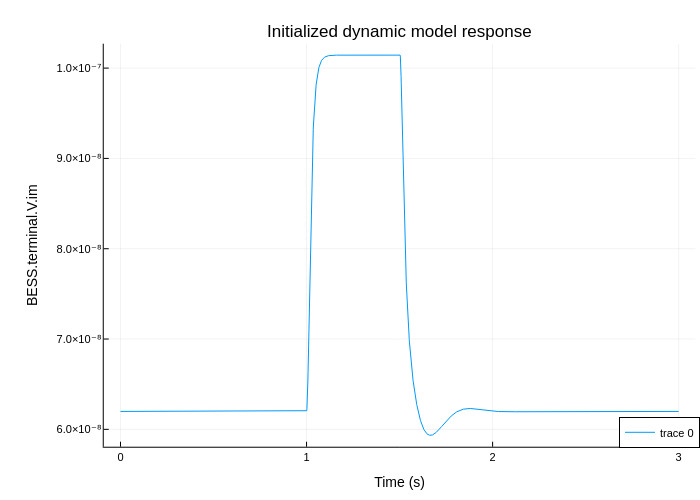

In [6]:
# Cell 6: Plot the initialized dynamic model
initialized_df = DataFrame(CSV.File(initialized_resultfile))

plotlyjs()
p = plot(initialized_df[!, "time"], initialized_df[!, PLOT_VARIABLE], label = [PLOT_VARIABLE])
plot!(p, legend = :bottomright, titlefontsize = 12, labelfontsize = 10)
title!(p, "Initialized dynamic model response")
xlabel!(p, "Time (s)")
ylabel!(p, PLOT_VARIABLE)
